# Neural Trajectory Divergence Analysis

This notebook implements analysis for detecting when STOP trial neural trajectories diverge from GO baseline.

Here we look at the data and explor the structure of GO trials.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import gammaln
import sys

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import importlib
import session_class
import cell_analysis
import multi_session_pca
importlib.reload(session_class)
importlib.reload(cell_analysis)
importlib.reload(multi_session_pca)

from session_class import Session
from cell_analysis import Cell
from multi_session_pca import MultiSessionPCA

print("Imports loaded successfully!")

Imports loaded successfully!


# Import MultiSessionPCA
sys.path.insert(0, str(Path.cwd().parent.parent))
from population_analysis.multi_session_pca import MultiSessionPCA

# Load data and validate sessions
pca_analyzer = MultiSessionPCA()
pca_analyzer.load_data(pickle_file)
pca_analyzer.get_session_statistics()
pca_analyzer.validate_all_sessions(verbose=False)

# Display validation results sorted by number of cells
validation_summary = pca_analyzer.validation_df[pca_analyzer.validation_df['is_valid']].copy()
validation_summary = validation_summary.sort_values('n_cells', ascending=False)

print("\nValid Sessions (sorted by neuron count):")
print("=" * 60)
for idx, row in validation_summary.iterrows():
    print(f"{row['session_id']}: {row['n_cells']} cells")

# Find best session
best_session = validation_summary.iloc[0]
print(f"\n{'='*60}")
print(f"BEST SESSION: {best_session['session_id']} with {best_session['n_cells']} cells")
print(f"{'='*60}")

## 1. Load Data, instantiate session and populate variables 

### 1.A Variables and Parameters

In [28]:
base_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'

session_id = 'fi211025a'  

dir_map = {0: 'Right', 180: 'Left'}

SSD_NUM = 2
EPOK = [-300, 300]
BIN_SIZE = 50  # Bin width in ms
BIN_STEP = 10   # Bin step size in ms (sliding windows)
FR_MIN = 1.0    # Hz
DIRECTION = 180  # Left (has more STOP trials)

### 1.B get instances

In [29]:
# Load MSN cell database
cell_df = pd.read_pickle(pickle_file)

# Select session 
session_data = cell_df[cell_df['trial_session'] == session_id]

# Create Session object
session = Session(session_data, verbose=True)

# Drop cells with missing trial type or direction data
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\nSession {session_id} loaded successfully!")
print(f"Number of cells after filtering: {session.n_cells}")
print(f"Total cell-trial combinations: {len(session.data)}")

Session fi211025a initialized:
  - Number of cells: 63
  - Total trials: 685
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

Session fi211025a loaded successfully!
Number of cells after filtering: 63
Total cell-trial combinations: 33136


### 1.C Clean data
Remove GO trials with reaction time greater than mean SSD length (pluse maybe a buffer)

In [30]:
session.data.columns

Index(['cell_ID', 'cell_type', 'maestro_ID', 'problem', 'grade', 'filename',
       'trial_name', 'reaction_time', 'go_cue', 'stop_cue', 'trial_failed',
       'ssd_len', 'ssd_number', 'type', 'first_relevant_saccade',
       'segs_durations', 'segs_times', 'trial_length', 'screen_rotation',
       'saccades', 'blinks', 'dir', 'neural_data', 'session', 'plexon_session',
       'trial_number', 'trial_session'],
      dtype='object')

In [31]:
def is_go_trial_with_valid_saccade(row, mean_ssd):
    if (row['type'] != 'GO'):
        return True
    if np.isnan(row['first_relevant_saccade']).any():
        return False
    saccade_onset = row['first_relevant_saccade'][0]
    return (saccade_onset - row['go_cue']) > mean_ssd

oring_data = session.data.copy()
print(oring_data.shape)

stop_trials = session.data[
    (session.data['type'] == 'STOP') & 
    (session.data['trial_failed'] == False) & 
    (session.data['dir'] == DIRECTION) &
    (session.data['ssd_number'] == SSD_NUM)
]
mean_ssd = stop_trials['ssd_len'].mean()
print(f"Mean SSD length for successful STOP SSD{SSD_NUM} trials: {mean_ssd:.2f} ms")

session.data[
    ~session.data.apply(lambda row: is_go_trial_with_valid_saccade(row, mean_ssd), axis=1)
]["trial_number"].value_counts().shape

# Filter GO trials
# session.data = session.data[
#     session.data.apply(lambda row: is_go_trial_with_valid_saccade(row, mean_ssd), axis=1)
# ]

# print(f"Number of removed trials after GO trial filtering: {oring_data.shape[0] - session.data.shape[0]}")

(33136, 27)
Mean SSD length for successful STOP SSD2 trials: 108.00 ms


(15,)

## 2. Check Trial Counts

Verify we have enough GO and STOP SSD2 trials for each direction.

In [32]:
# Count successful trials for GO and STOP SSD2 by direction

results = []
for dir in [0, 180]:
    dir_name = dir_map[dir]
    
    # GO trials (successful only) - count unique trial numbers
    go_count = len(session.data[
        (session.data['type'] == 'GO') & 
        (session.data['dir'] == dir) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'GO', 'Trial Count': go_count})
    
    # STOP SSD2 trials (successful only)
    stop_count = len(session.data[
        (session.data['type'] == 'STOP') & 
        (session.data['dir'] == dir) & 
        (session.data['ssd_number'] == SSD_NUM) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'STOP SSD2', 'Trial Count': stop_count})

results_df = pd.DataFrame(results)
print("\nSuccessful Trial Counts:")
print("=" * 40)
print(results_df.to_string(index=False))


Successful Trial Counts:
Direction      Type  Trial Count
    Right        GO          197
    Right STOP SSD2           13
     Left        GO          182
     Left STOP SSD2           11


In [33]:
session.data['first_relevant_saccade']

647083    [1267, 1340]
647084    [1267, 1340]
647085    [1267, 1340]
647086    [1267, 1340]
647089    [1267, 1340]
              ...     
681732    [1809, 1857]
681733    [1809, 1857]
681734    [1809, 1857]
681735    [1809, 1857]
681736    [1809, 1857]
Name: first_relevant_saccade, Length: 33136, dtype: object

## 3. Create Trial Number Lists

Extract unique trial numbers for GO and STOP trials by direction.

In [34]:
def filter_trials(session_data, trial_type, direction, ssd_number=None, success_only=True):
    """
    Filter trials based on specified conditions.
    
    Parameters:
    -----------
    session_data : DataFrame
        Session data containing trial information
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 (right) or 180 (left)
    ssd_number : float, optional
        SSD level (1.0-4.0) for STOP/CONT trials
    success_only : bool
        If True, only include trials where trial_failed == False
    
    Returns:
    --------
    DataFrame : Filtered session data
    """
    # Base filter
    mask = (session_data['type'] == trial_type) & (session_data['dir'] == direction)
    
    # Add success filter if requested
    if success_only:
        mask &= (session_data['trial_failed'] == False)
    
    # Add SSD filter if specified
    if ssd_number is not None:
        mask &= (session_data['ssd_number'] == ssd_number)
    
    return session_data[mask]


def get_trial_numbers(session_data, trial_type, direction, ssd_number=None, success_only=True):
    """
    Extract unique trial numbers for specified conditions.
    
    Parameters:
    -----------
    session_data : DataFrame
        Session data containing trial information
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 (right) or 180 (left)
    ssd_number : float, optional
        SSD level (1.0-4.0) for STOP/CONT trials
    success_only : bool
        If True, only include trials where trial_failed == False
    
    Returns:
    --------
    list : Sorted list of unique trial numbers
    """
    filtered_data = filter_trials(session_data, trial_type, direction, ssd_number, success_only)
    return sorted(filtered_data['trial_number'].unique())


# Create trial lists for GO and STOP trials
trial_lists = {}

for dir, dir_name in dir_map.items():
    # GO trials
    trial_lists[f'go_{dir_name.lower()}'] = get_trial_numbers(
        session.data, 'GO', dir
    )
    
    # STOP trials with specified SSD
    trial_lists[f'stop_{dir_name.lower()}'] = get_trial_numbers(
        session.data, 'STOP', dir, ssd_number=SSD_NUM
    )

# Extract to individual variables for convenience
go_right_trials = trial_lists['go_right']
go_left_trials = trial_lists['go_left']
stop_right_trials = trial_lists['stop_right']
stop_left_trials = trial_lists['stop_left']

# Display results
print("Trial Number Lists:")
print("=" * 60)
print(f"\nGO Right (n={len(go_right_trials)}):")
print(f"\nGO Left (n={len(go_left_trials)}):")
print(f"\nSTOP SSD{SSD_NUM} Right (n={len(stop_right_trials)}):")
print(f"\nSTOP SSD{SSD_NUM} Left (n={len(stop_left_trials)}):")

Trial Number Lists:

GO Right (n=197):

GO Left (n=182):

STOP SSD2 Right (n=13):

STOP SSD2 Left (n=11):


## 4. Neuron Distribution per Trial

Analyze how many neurons are recorded for each trial.

Left STOP SSD2 Trials - Neurons per Trial Distribution:
Total trials: 11
Mean neurons per trial: 49.09
Median neurons per trial: 49
Min neurons per trial: 31
Max neurons per trial: 58

Distribution:
cell_ID
31    1
33    1
44    1
46    1
49    2
56    1
58    4
Name: count, dtype: int64


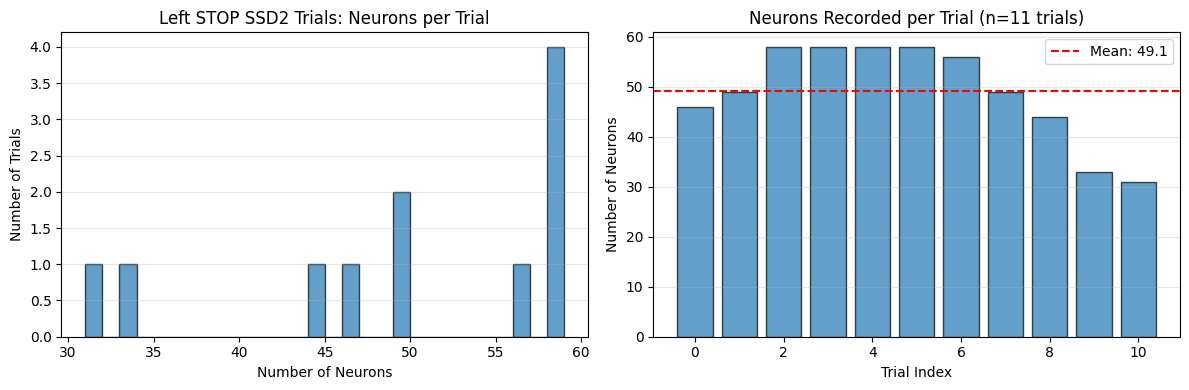



Trial-by-trial breakdown:
Trial 84: 46 neurons
Trial 112: 49 neurons
Trial 261: 58 neurons
Trial 332: 58 neurons
Trial 409: 58 neurons
Trial 412: 58 neurons
Trial 449: 56 neurons
Trial 528: 49 neurons
Trial 585: 44 neurons
Trial 696: 33 neurons
Trial 707: 31 neurons


In [35]:
# Parameters for analysis
analysis_trial_type = 'STOP'
analysis_direction = DIRECTION
analysis_ssd_num = SSD_NUM

# Filter trials using the filter function
filtered_data = filter_trials(
    session.data, 
    trial_type=analysis_trial_type, 
    direction=analysis_direction, 
    ssd_number=analysis_ssd_num,
    success_only=True
)

# Count unique cells per trial
neurons_per_trial = filtered_data.groupby('trial_number')['cell_ID'].nunique().sort_index()

# Summary statistics
dir_name = dir_map[analysis_direction]
print(f"{dir_name} {analysis_trial_type} SSD{analysis_ssd_num} Trials - Neurons per Trial Distribution:")
print("=" * 60)
print(f"Total trials: {len(neurons_per_trial)}")
print(f"Mean neurons per trial: {neurons_per_trial.mean():.2f}")
print(f"Median neurons per trial: {neurons_per_trial.median():.0f}")
print(f"Min neurons per trial: {neurons_per_trial.min()}")
print(f"Max neurons per trial: {neurons_per_trial.max()}")
print(f"\nDistribution:")
print(neurons_per_trial.value_counts().sort_index())

# Visualize distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax1.hist(neurons_per_trial, bins=range(neurons_per_trial.min(), neurons_per_trial.max() + 2), 
         edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Neurons')
ax1.set_ylabel('Number of Trials')
ax1.set_title(f'{dir_name} {analysis_trial_type} SSD{analysis_ssd_num} Trials: Neurons per Trial')
ax1.grid(axis='y', alpha=0.3)

# Per-trial view
ax2.bar(range(len(neurons_per_trial)), neurons_per_trial.values, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Trial Index')
ax2.set_ylabel('Number of Neurons')
ax2.set_title(f'Neurons Recorded per Trial (n={len(neurons_per_trial)} trials)')
ax2.axhline(y=neurons_per_trial.mean(), color='r', linestyle='--', label=f'Mean: {neurons_per_trial.mean():.1f}')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show trial-by-trial details
print(f"\n\nTrial-by-trial breakdown:")
print("=" * 60)
for trial_num, n_neurons in neurons_per_trial.items():
    print(f"Trial {trial_num}: {n_neurons} neurons")

### 4.A Neuron-Trial Recording Heatmap

Visualize which neurons were recorded for each trial.

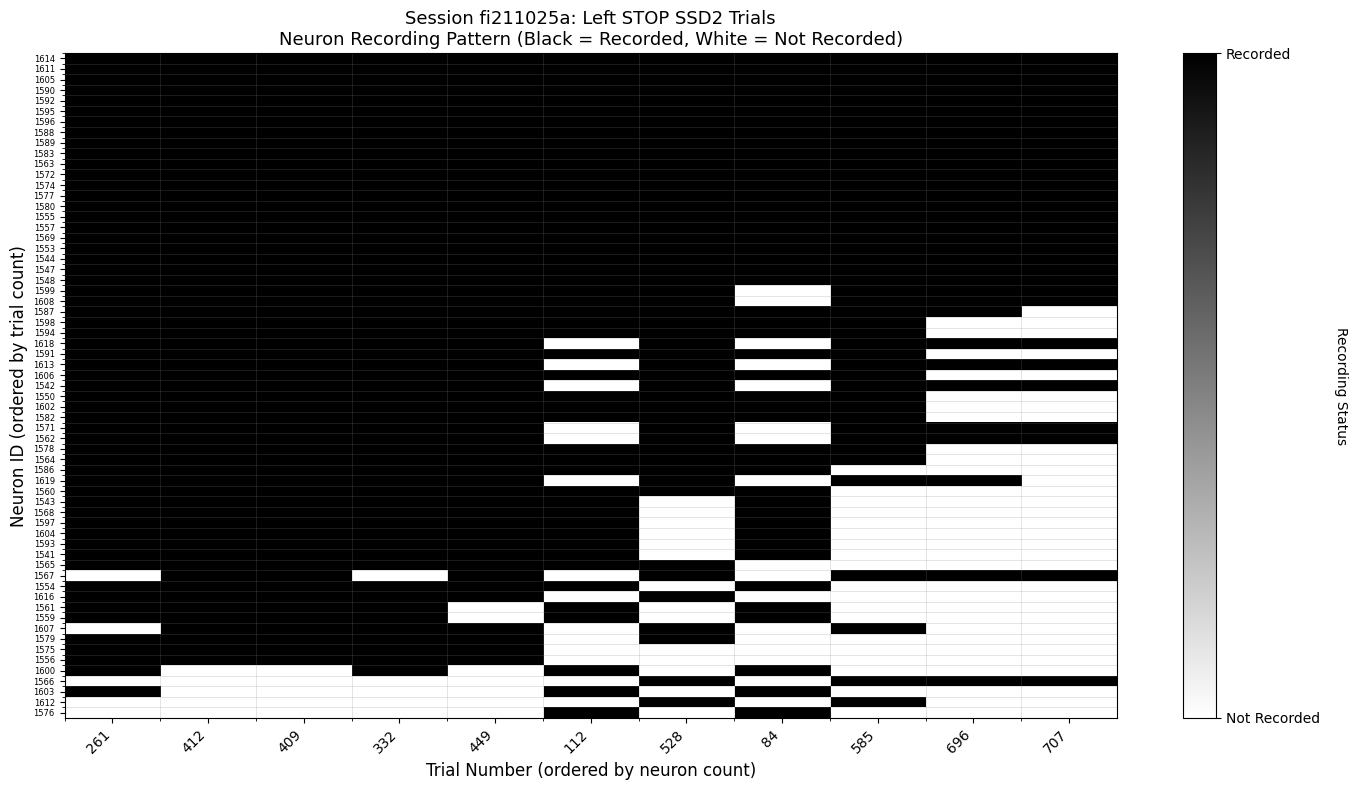


Recording Matrix Summary:
Session: fi211025a
Total neurons: 63
Total trials: 11
Total possible recordings: 693
Actual recordings: 540
Recording density: 77.92%

Neurons per trial: min=31, max=58, mean=49.1
Trials per neuron: min=2, max=11, mean=8.6

Trials ordered by neuron count (most to least):
[np.int64(261), np.int64(412), np.int64(409), np.int64(332), np.int64(449), np.int64(112), np.int64(528), np.int64(84), np.int64(585), np.int64(696), np.int64(707)]

Neurons ordered by trial count (most to least):
[np.int64(1614), np.int64(1611), np.int64(1605), np.int64(1590), np.int64(1592), np.int64(1595), np.int64(1596), np.int64(1588), np.int64(1589), np.int64(1583), np.int64(1563), np.int64(1572), np.int64(1574), np.int64(1577), np.int64(1580), np.int64(1555), np.int64(1557), np.int64(1569), np.int64(1553), np.int64(1544), np.int64(1547), np.int64(1548), np.int64(1599), np.int64(1608), np.int64(1587), np.int64(1598), np.int64(1594), np.int64(1618), np.int64(1591), np.int64(1613), np.int

In [36]:
def plot_neuron_trial_heatmap(filtered_data, session_id, trial_type, direction, ssd_number, dir_map,
                              figsize=(14, 8), show=True):
    """
    Create heatmap showing which neurons were recorded in which trials.

    Parameters:
    -----------
    filtered_data : DataFrame
        Filtered trial data
    session_id : str
        Session identifier
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 (right) or 180 (left)
    ssd_number : int
        SSD level
    dir_map : dict
        Direction mapping {0: 'Right', 180: 'Left'}
    figsize : tuple
        Figure size
    show : bool
        Whether to display the plot

    Returns:
    --------
    tuple : (fig, ax, recording_matrix, summary_stats, ordered_trial_numbers, ordered_cell_ids)
    """
    # Get unique trial numbers and cell IDs
    trial_numbers = sorted(filtered_data['trial_number'].unique())
    cell_ids = sorted(filtered_data['cell_ID'].unique())

    # Create binary matrix: 1 if neuron recorded in trial, 0 otherwise
    recording_matrix = np.zeros((len(cell_ids), len(trial_numbers)))

    # Fill matrix
    for i, cell_id in enumerate(cell_ids):
        for j, trial_num in enumerate(trial_numbers):
            exists = ((filtered_data['cell_ID'] == cell_id) &
                      (filtered_data['trial_number'] == trial_num)).any()
            recording_matrix[i, j] = 1 if exists else 0

    # Compute coverage
    neurons_per_trial = recording_matrix.sum(axis=0)  # For each trial (column)
    trials_per_neuron = recording_matrix.sum(axis=1)  # For each neuron (row)

    # Sort trials by neurons_per_trial (descending: most neurons first)
    trial_order = np.argsort(neurons_per_trial)[::-1]
    ordered_trial_numbers = [trial_numbers[i] for i in trial_order]

    # Sort neurons by trials_per_neuron (descending: most trials first)
    neuron_order = np.argsort(trials_per_neuron)[::-1]
    ordered_cell_ids = [cell_ids[i] for i in neuron_order]

    # Reorder the recording matrix
    recording_matrix_ordered = recording_matrix[neuron_order, :][:, trial_order]

    # Compute summary statistics (on reordered matrix)
    neurons_per_trial_ordered = recording_matrix_ordered.sum(axis=0)
    trials_per_neuron_ordered = recording_matrix_ordered.sum(axis=1)

    summary_stats = {
        'n_neurons': len(cell_ids),
        'n_trials': len(trial_numbers),
        'total_possible': len(cell_ids) * len(trial_numbers),
        'actual_recordings': int(recording_matrix_ordered.sum()),
        'recording_density': recording_matrix_ordered.mean(),
        'neurons_per_trial_min': int(neurons_per_trial_ordered.min()) if len(neurons_per_trial_ordered) > 0 else 0,
        'neurons_per_trial_max': int(neurons_per_trial_ordered.max()) if len(neurons_per_trial_ordered) > 0 else 0,
        'neurons_per_trial_mean': neurons_per_trial_ordered.mean() if len(neurons_per_trial_ordered) > 0 else 0,
        'trials_per_neuron_min': int(trials_per_neuron_ordered.min()) if len(trials_per_neuron_ordered) > 0 else 0,
        'trials_per_neuron_max': int(trials_per_neuron_ordered.max()) if len(trials_per_neuron_ordered) > 0 else 0,
        'trials_per_neuron_mean': trials_per_neuron_ordered.mean() if len(trials_per_neuron_ordered) > 0 else 0,
    }

    # Create heatmap
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(recording_matrix_ordered, aspect='auto', cmap='binary', interpolation='nearest')

    # Set ticks and labels
    ax.set_xticks(range(len(ordered_trial_numbers)))
    ax.set_xticklabels(ordered_trial_numbers, rotation=45, ha='right')
    ax.set_yticks(range(len(ordered_cell_ids)))
    ax.set_yticklabels(ordered_cell_ids, fontsize=max(6, min(10, 400 // len(ordered_cell_ids))))

    # Labels and title
    ax.set_xlabel('Trial Number (ordered by neuron count)', fontsize=12)
    ax.set_ylabel('Neuron ID (ordered by trial count)', fontsize=12)
    dir_name = dir_map[direction]
    ax.set_title(f'Session {session_id}: {dir_name} {trial_type} SSD{ssd_number} Trials\n' +
                 f'Neuron Recording Pattern (Black = Recorded, White = Not Recorded)', fontsize=13)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.set_label('Recording Status', rotation=270, labelpad=20)
    cbar.ax.set_yticklabels(['Not Recorded', 'Recorded'])

    # Add grid for better readability
    ax.set_xticks(np.arange(len(ordered_trial_numbers)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(ordered_cell_ids)) - 0.5, minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

    plt.tight_layout()

    if show:
        plt.show()

    return fig, ax, recording_matrix_ordered, summary_stats, ordered_trial_numbers, ordered_cell_ids


# Use the function to plot heatmap for current session
filtered_data = filter_trials(
    session.data, 
    trial_type=analysis_trial_type, 
    direction=analysis_direction, 
    ssd_number=analysis_ssd_num,
    success_only=True
)

results = plot_neuron_trial_heatmap(
    filtered_data, 
    session_id, 
    analysis_trial_type, 
    analysis_direction, 
    analysis_ssd_num, 
    dir_map
)

# Unpack results (now includes ordered lists)
fig, ax, recording_matrix, summary_stats, ordered_trial_numbers, ordered_cell_ids = results

# Print summary statistics
print(f"\nRecording Matrix Summary:")
print("=" * 60)
print(f"Session: {session_id}")
print(f"Total neurons: {summary_stats['n_neurons']}")
print(f"Total trials: {summary_stats['n_trials']}")
print(f"Total possible recordings: {summary_stats['total_possible']}")
print(f"Actual recordings: {summary_stats['actual_recordings']}")
print(f"Recording density: {summary_stats['recording_density']:.2%}")
print(f"\nNeurons per trial: min={summary_stats['neurons_per_trial_min']}, "
      f"max={summary_stats['neurons_per_trial_max']}, "
      f"mean={summary_stats['neurons_per_trial_mean']:.1f}")
print(f"Trials per neuron: min={summary_stats['trials_per_neuron_min']}, "
      f"max={summary_stats['trials_per_neuron_max']}, "
      f"mean={summary_stats['trials_per_neuron_mean']:.1f}")
print(f"\nTrials ordered by neuron count (most to least):")
print(ordered_trial_numbers)
print(f"\nNeurons ordered by trial count (most to least):")
print(ordered_cell_ids)

## 5. Session Comparison

Compare recording density across all valid sessions to find the best session for analysis.

In [37]:
def compute_session_recording_density(session_df, trial_type, direction, ssd_number, success_only=True):
    """
    Compute recording density for a session.
    
    Parameters:
    -----------
    session_df : DataFrame
        Session data
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 or 180
    ssd_number : int
        SSD level
    success_only : bool
        Only successful trials
        
    Returns:
    --------
    dict : Statistics including recording density
    """
    # Filter trials
    filtered = filter_trials(session_df, trial_type, direction, ssd_number, success_only)
    
    if len(filtered) == 0:
        return {
            'n_neurons': 0,
            'n_trials': 0,
            'total_possible': 0,
            'actual_recordings': 0,
            'recording_density': 0.0,
            'expected_density': 0.0
        }
    
    # Get unique neurons and trials
    n_neurons = filtered['cell_ID'].nunique()
    n_trials = filtered['trial_number'].nunique()
    total_possible = n_neurons * n_trials
    actual_recordings = len(filtered)
    recording_density = actual_recordings / total_possible if total_possible > 0 else 0.0
    expected_density = recording_density * n_neurons
    
    return {
        'n_neurons': n_neurons,
        'n_trials': n_trials,
        'total_possible': total_possible,
        'actual_recordings': actual_recordings,
        'recording_density': recording_density,
        'expected_density': expected_density
    }



print("Creating pca_analyzer object...")
pca_analyzer = MultiSessionPCA()
pca_analyzer.load_data(pickle_file)
pca_analyzer.get_session_statistics()
pca_analyzer.validate_all_sessions(verbose=False)
print(f"Validated {len(pca_analyzer.valid_sessions)} sessions")

# Analyze all valid sessions
print("\nComputing recording density for all valid sessions...")
print("=" * 80)

session_comparison = []

for idx, row in pca_analyzer.validation_df[pca_analyzer.validation_df['is_valid']].iterrows():
    sess_id = row['session_id']
    
    # Get session data
    sess_data = cell_df[cell_df['trial_session'] == sess_id]
    
    # Create Session object and drop incomplete cells
    sess_obj = Session(sess_data, verbose=False)
    sess_obj.drop_cells_with_missing_trial_type_or_dir_data()
    
    # Compute stats for both directions
    for direction in [0, 180]:
        stats = compute_session_recording_density(
            sess_obj.data, 
            trial_type='STOP', 
            direction=direction, 
            ssd_number=SSD_NUM, 
            success_only=True
        )
        
        if stats['n_trials'] > 0:  # Only include if there are trials
            session_comparison.append({
                'session_id': sess_id,
                'direction': dir_map[direction],
                'n_neurons': stats['n_neurons'],
                'n_trials': stats['n_trials'],
                'total_possible': stats['total_possible'],
                'actual_recordings': stats['actual_recordings'],
                'recording_density': stats['recording_density'],
                'expected_density': stats['expected_density']
            })

# Create DataFrame
comparison_df = pd.DataFrame(session_comparison)
comparison_df = comparison_df.sort_values('expected_density', ascending=False)

# Summary statistics
print(f"\nTop 10 Sessions by Expected Density:")
print("=" * 80)
top_10 = comparison_df.head(10)[['session_id', 'direction', 'n_neurons', 'n_trials', 
                                   'recording_density', 'expected_density']].copy()
top_10['recording_density'] = top_10['recording_density'].apply(lambda x: f"{x:.2%}")
print(top_10.to_string(index=False))

# Find absolute best
best_row = comparison_df.iloc[0]
print(f"\n{'='*80}")
print(f"BEST CONFIGURATION:")
print(f"  Session: {best_row['session_id']}")
print(f"  Direction: {best_row['direction']}")
print(f"  Neurons: {best_row['n_neurons']}")
print(f"  Trials: {best_row['n_trials']}")
print(f"  Recording Density: {best_row['recording_density']:.2%}")
print(f"  Expected Density: {best_row['expected_density']:.2f}")
print(f"{'='*80}")

Creating pca_analyzer object...
Loading data from: /home/barak/Projects/population-analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 770,705 cell-trial combinations
  Total sessions: 60
  Total unique cells: 1414
✓ Session statistics computed for 60 sessions
  Excluded sessions: 1
  Candidate sessions: 59
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
Validated 40 sessions

Computing recording density for all valid sessions...
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.

Top 10 Sessions by Expected Density:
session_id direction  n_neurons  n_trials recording_density  expected_density
 fi211110a      Left         84        18            62.04%         52.111111
 fi211110a     Right         84        23            60.66%         50.956522
 fi211025a      Left         63        11            77.92%         49.090909
 fi211102a     Righ

### 5.1 Add Neural Tuning Analysis

Test neurons for task and direction tuning using ANOVA.

In [38]:
from scipy import stats

# Analysis windows (from tuning analysis methodology)
TUNING_WINDOWS = {
    'baseline': [-500, 0],  # Pre-cue baseline
    'task': [0, 500],  # Task execution
    'direction': [0, 500],  # Movement period for direction tuning
}

def get_firing_rates(cell, align_event, window, trial_type=None, direction=None, success_only=True):
    """
    Extract firing rates for specific conditions.
    
    Parameters:
    -----------
    cell : Cell
        Cell object
    align_event : str
        'go_cue' or 'stop_cue'
    window : list
        Time window [start, end] in ms
    trial_type : str, optional
        'GO', 'STOP', or 'CONT'
    direction : int, optional
        0 (right) or 180 (left)
    success_only : bool
        Include only successful trials
    
    Returns:
    --------
    np.array : Firing rates in spikes/sec
    """
    df = cell.filter_trials(trial_type=trial_type, direction=direction, success_only=success_only)
    
    rates = []
    for _, row in df.iterrows():
        if align_event == 'go_cue':
            t0 = row['go_cue']
        elif align_event == 'stop_cue':
            t0 = row['stop_cue']
        else:
            raise ValueError(f"Unknown align_event: {align_event}")
        
        if pd.isna(t0):
            continue
            
        spikes = np.array(row['neural_data'], dtype=float)
        aligned_spikes = spikes - t0
        
        count = np.sum((aligned_spikes >= window[0]) & (aligned_spikes <= window[1]))
        duration = (window[1] - window[0]) / 1000.0
        rates.append(count / duration)
        
    return np.array(rates)


def test_cell_tuning(cell, alpha=0.05):
    """
    Test if a cell is tuned to task and/or direction.
    
    Parameters:
    -----------
    cell : Cell
        Cell object
    alpha : float
        Significance threshold (default: 0.05)
        
    Returns:
    --------
    dict : Tuning test results
    """
    results = {
        'cell_id': cell.cell_id,
        'task_modulated': False,
        'direction_tuned': False,
        'task_p': np.nan,
        'direction_p': np.nan,
    }
    
    # Test 1: Task modulation (baseline vs GO period)
    try:
        baseline = get_firing_rates(cell, 'go_cue', TUNING_WINDOWS['baseline'], trial_type='GO')
        task = get_firing_rates(cell, 'go_cue', TUNING_WINDOWS['task'], trial_type='GO')
        
        if len(baseline) >= 5 and len(task) >= 5:
            _, p_val = stats.f_oneway(baseline, task)
            results['task_p'] = p_val
            results['task_modulated'] = p_val < alpha
    except:
        pass
    
    # Test 2: Direction tuning (left vs right during GO trials)
    try:
        go_left = get_firing_rates(cell, 'go_cue', TUNING_WINDOWS['direction'], trial_type='GO', direction=180)
        go_right = get_firing_rates(cell, 'go_cue', TUNING_WINDOWS['direction'], trial_type='GO', direction=0)
        
        if len(go_left) >= 5 and len(go_right) >= 5:
            _, p_val = stats.f_oneway(go_left, go_right)
            results['direction_p'] = p_val
            results['direction_tuned'] = p_val < alpha
    except:
        pass
    
    # Overall tuning status
    results['is_tuned'] = results['task_modulated'] or results['direction_tuned']
    
    return results


def compute_session_tuning_stats(session, alpha=0.05):
    """
    Compute tuning statistics for all cells in a session.
    
    Parameters:
    -----------
    session : Session
        Session object
    alpha : float
        Significance threshold
        
    Returns:
    --------
    dict : Session-level tuning statistics
    """
    tuning_results = []
    
    for cell_id in session.cell_ids:
        try:
            cell = session.get_cell(cell_id)
            result = test_cell_tuning(cell, alpha=alpha)
            tuning_results.append(result)
        except:
            continue
    
    if len(tuning_results) == 0:
        return {
            'n_cells': 0,
            'n_task_modulated': 0,
            'n_direction_tuned': 0,
            'n_tuned': 0,
            'pct_task_modulated': 0.0,
            'pct_direction_tuned': 0.0,
            'pct_tuned': 0.0,
        }
    
    n_cells = len(tuning_results)
    n_task = sum(r['task_modulated'] for r in tuning_results)
    n_direction = sum(r['direction_tuned'] for r in tuning_results)
    n_tuned = sum(r['is_tuned'] for r in tuning_results)
    
    return {
        'n_cells': n_cells,
        'n_task_modulated': n_task,
        'n_direction_tuned': n_direction,
        'n_tuned': n_tuned,
        'pct_task_modulated': 100 * n_task / n_cells,
        'pct_direction_tuned': 100 * n_direction / n_cells,
        'pct_tuned': 100 * n_tuned / n_cells,
    }

print("✓ Tuning analysis functions defined")

✓ Tuning analysis functions defined


In [39]:
def compute_session_recording_density(session_df, trial_type, direction, ssd_number, success_only=True):
    """
    Compute recording density for a session.
    
    Parameters:
    -----------
    session_df : DataFrame
        Session data
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 or 180
    ssd_number : int
        SSD level
    success_only : bool
        Only successful trials
        
    Returns:
    --------
    dict : Statistics including recording density
    """
    # Filter trials
    filtered = filter_trials(session_df, trial_type, direction, ssd_number, success_only)
    
    if len(filtered) == 0:
        return {
            'n_neurons': 0,
            'n_trials': 0,
            'total_possible': 0,
            'actual_recordings': 0,
            'recording_density': 0.0,
            'expected_density': 0.0
        }
    
    # Get unique neurons and trials
    n_neurons = filtered['cell_ID'].nunique()
    n_trials = filtered['trial_number'].nunique()
    total_possible = n_neurons * n_trials
    actual_recordings = len(filtered)
    recording_density = actual_recordings / total_possible if total_possible > 0 else 0.0
    expected_density = recording_density * n_neurons
    
    return {
        'n_neurons': n_neurons,
        'n_trials': n_trials,
        'total_possible': total_possible,
        'actual_recordings': actual_recordings,
        'recording_density': recording_density,
        'expected_density': expected_density
    }


# Create/load pca_analyzer if not already defined
try:
    pca_analyzer
    print("Using existing pca_analyzer object...")
except NameError:
    print("Creating pca_analyzer object...")
    pca_analyzer = MultiSessionPCA()
    pca_analyzer.load_data(pickle_file)
    pca_analyzer.get_session_statistics()
    pca_analyzer.validate_all_sessions(verbose=False)
    print(f"Validated {len(pca_analyzer.valid_sessions)} sessions")

# Analyze all valid sessions with recording density AND tuning
print("\nComputing recording density and tuning for all valid sessions...")
print("=" * 80)

session_comparison = []

for idx, row in pca_analyzer.validation_df[pca_analyzer.validation_df['is_valid']].iterrows():
    sess_id = row['session_id']
    
    # Get session data
    sess_data = cell_df[cell_df['trial_session'] == sess_id]
    
    # Create Session object and drop incomplete cells
    sess_obj = Session(sess_data, verbose=False)
    sess_obj.drop_cells_with_missing_trial_type_or_dir_data()
    
    # Compute tuning stats for this session
    tuning_stats = compute_session_tuning_stats(sess_obj, alpha=0.05)
    
    # Compute recording density stats for both directions
    for direction in [0, 180]:
        rec_stats = compute_session_recording_density(
            sess_obj.data, 
            trial_type='STOP', 
            direction=direction, 
            ssd_number=SSD_NUM, 
            success_only=True
        )
        
        if rec_stats['n_trials'] > 0:  # Only include if there are trials
            # Compute quality score: expected_density * pct_tuned
            quality_score = rec_stats['expected_density'] * (tuning_stats['pct_tuned'] / 100.0)
            
            session_comparison.append({
                'session_id': sess_id,
                'direction': dir_map[direction],
                'n_neurons': rec_stats['n_neurons'],
                'n_trials': rec_stats['n_trials'],
                'recording_density': rec_stats['recording_density'],
                'expected_density': rec_stats['expected_density'],
                'n_tuned': tuning_stats['n_tuned'],
                'pct_tuned': tuning_stats['pct_tuned'],
                'pct_task_modulated': tuning_stats['pct_task_modulated'],
                'pct_direction_tuned': tuning_stats['pct_direction_tuned'],
                'quality_score': quality_score,
            })

# Create DataFrame
comparison_df = pd.DataFrame(session_comparison)
comparison_df = comparison_df.sort_values('quality_score', ascending=False)

# Display top sessions by quality score
print(f"\nTop 10 Sessions by Quality Score (expected_density × pct_tuned):")
print("=" * 80)
top_10 = comparison_df.head(10)[['session_id', 'direction', 'n_neurons', 'n_trials', 
                                   'recording_density', 'expected_density', 
                                   'pct_tuned', 'quality_score']].copy()
top_10['recording_density'] = top_10['recording_density'].apply(lambda x: f"{x:.2%}")
top_10['pct_tuned'] = top_10['pct_tuned'].apply(lambda x: f"{x:.1f}%")
top_10['quality_score'] = top_10['quality_score'].apply(lambda x: f"{x:.2f}")
print(top_10.to_string(index=False))

# Find absolute best
best_row = comparison_df.iloc[0]
print(f"\n{'='*80}")
print(f"BEST CONFIGURATION (by quality score):")
print(f"  Session: {best_row['session_id']}")
print(f"  Direction: {best_row['direction']}")
print(f"  Neurons: {best_row['n_neurons']}")
print(f"  Trials: {best_row['n_trials']}")
print(f"  Recording Density: {best_row['recording_density']:.2%}")
print(f"  Expected Density: {best_row['expected_density']:.2f}")
print(f"  Tuned Neurons: {best_row['n_tuned']} ({best_row['pct_tuned']:.1f}%)")
print(f"  Quality Score: {best_row['quality_score']:.2f}")
print(f"{'='*80}")

Using existing pca_analyzer object...

Computing recording density and tuning for all valid sessions...
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.

Top 10 Sessions by Quality Score (expected_density × pct_tuned):
session_id direction  n_neurons  n_trials recording_density  expected_density pct_tuned quality_score
 fi211025a      Left         63        11            77.92%         49.090909     74.6%         36.62
 fi211025a     Right         62        13            77.67%         48.153846     74.6%         35.92
 fi211110a      Left         84        18            62.04%         52.111111     64.3%         33.50
 fi211110a     Right         84        23            60.66%         50.956522     64.3%         32.76
 fi211026a     Right         76        18            64.33%         48.888889     65.8%         32.16
 fi211026a      Left         75        14            62.57%         46.928571     65.8%         30.87
 fi211018a 